# Data Preparation

In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ranaghulamnabi/customer-personality-and-marketing-campaign-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 62.0k/62.0k [00:00<00:00, 45.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ranaghulamnabi/customer-personality-and-marketing-campaign-dataset/versions/1
['marketing_campaign.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(f"{path}/marketing_campaign.csv", sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (2240, 29)

Column Names:
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts       

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [6]:
print("Missing Income values:", df["Income"].isnull().sum())
print("Percentage:", (df["Income"].isnull().sum() / len(df)) * 100)

Missing Income values: 24
Percentage: 1.0714285714285714


In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


The dataset contained 24 missing values in the Income feature. Since this represented a small proportion of the dataset, i imputed the missing values using the median income. because income data may be skewed and influenced by extreme values.

**Numerical Features**

For this project, i am selecting these 8 numerical features:

* Income — customer's purchasing capacity
* Recency — days since the customer's last purchase
* MntWines — amount spent on wine
* MntMeatProducts — amount spent on meat products
* NumDealsPurchases — purchases made using deals
* NumWebPurchases — purchases made through the website
* NumCatalogPurchases — purchases made through catalogs
* NumStorePurchases — purchases made directly in stores

Also the ID column was removed from the clustering features because it is only a unique customer identifier and does not represent customer behavior

In [12]:
features = [
    "Income",
    "Recency",
    "MntWines",
    "MntMeatProducts",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Matrix Shape:", X.shape)

X.head()

Selected Features:
['Income', 'Recency', 'MntWines', 'MntMeatProducts', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

Feature Matrix Shape: (2239, 8)


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,58138.0,58,635,546,3,8,10,4
1,46344.0,38,11,6,2,1,1,2
2,71613.0,26,426,127,1,8,2,10
3,26646.0,26,11,20,2,2,0,4
4,58293.0,94,173,118,5,5,3,6


In [9]:
display(X.describe())

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,49.109375,303.935714,166.950000,2.325000,4.084821,2.662054,5.790179
std,25037.955891,28.962453,336.597393,225.715373,1.932238,2.778714,2.923101,3.250958
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35538.750000,24.000000,23.750000,16.000000,1.000000,2.000000,0.000000,3.000000
50%,51381.500000,49.000000,173.500000,67.000000,2.000000,4.000000,2.000000,5.000000
75%,68289.750000,74.000000,504.250000,232.000000,3.000000,6.000000,4.000000,8.000000
max,666666.000000,99.000000,1493.000000,1725.000000,15.000000,27.000000,28.000000,13.000000


In [10]:
df[df["Income"] > 200000][["ID", "Income"]]

,ID,Income
2233,9432,666666.0


In [11]:
df = df[df["Income"] != 666666].copy()

print("New dataset shape:", df.shape)
print("New maximum income:", df["Income"].max())

New dataset shape: (2239, 29)
New maximum income: 162397.0


outlier in income so i will remove its row and re-run cell 8

In [ ]:
features = [
    "Income",
    "Recency",
    "MntWines",
    "MntMeatProducts",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Matrix Shape:", X.shape)

X.head()

In [13]:
negative_counts = (X < 0).sum()

print("Negative Values in Selected Features:")
print(negative_counts)

Negative Values in Selected Features:
Income                 0
Recency                0
MntWines               0
MntMeatProducts        0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
dtype: int64


no negative values!

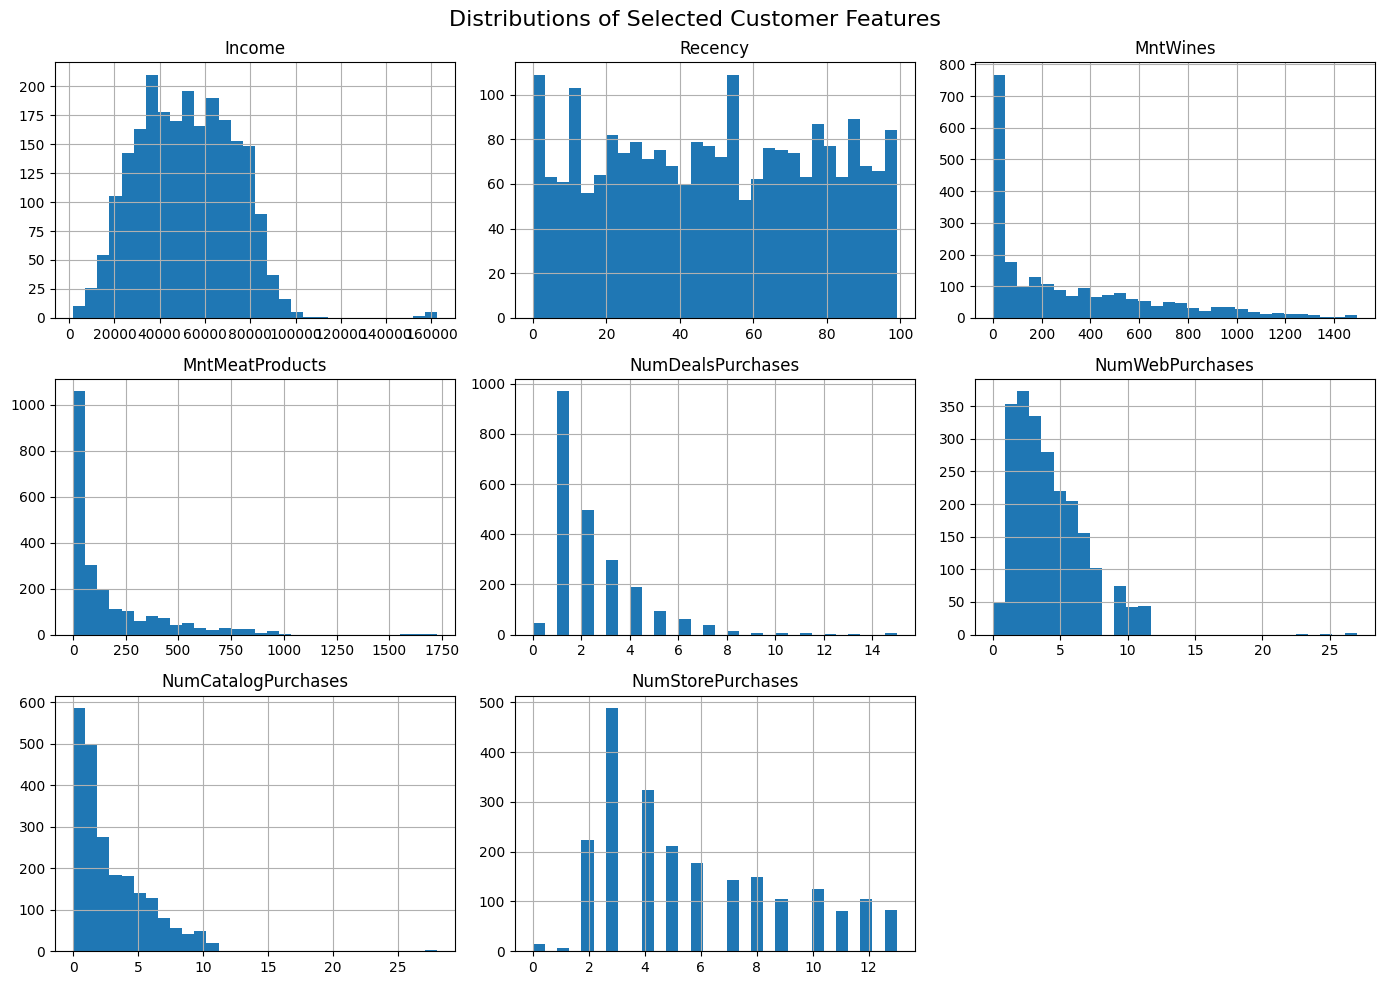

In [14]:
X.hist(figsize=(14, 10), bins=30)

plt.suptitle("Distributions of Selected Customer Features", fontsize=16)
plt.tight_layout()

plt.show()

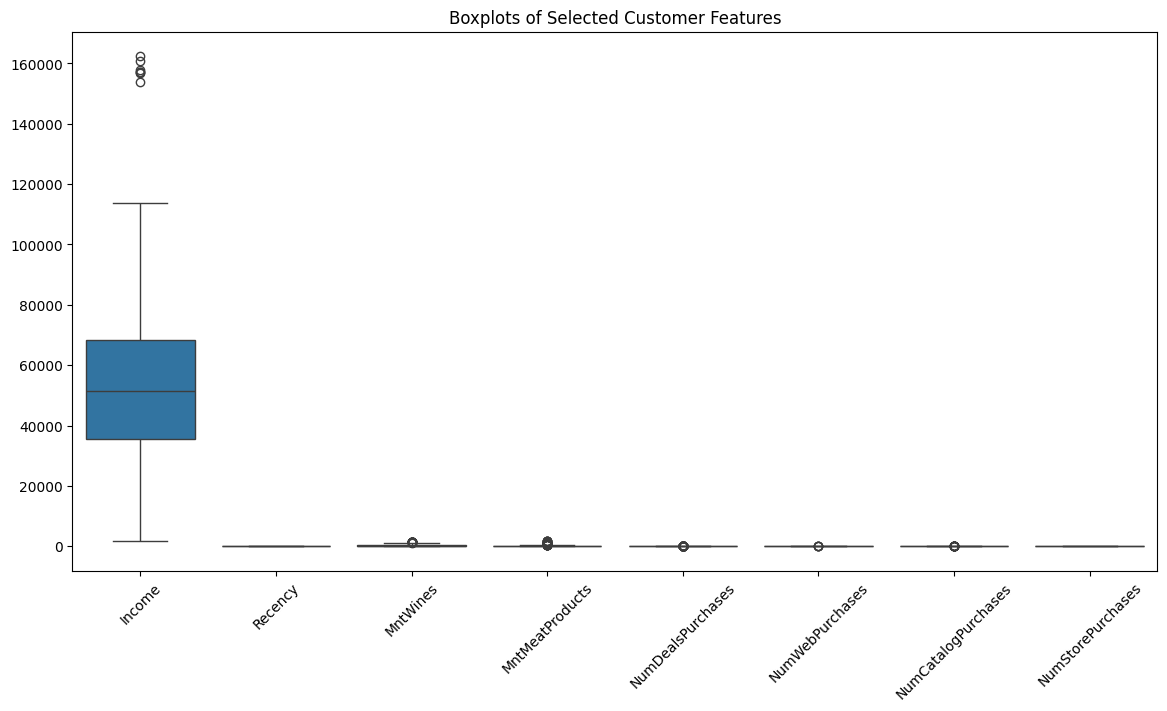

In [15]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=X)

plt.title("Boxplots of Selected Customer Features")
plt.xticks(rotation=45)

plt.show()

some features had a much larger range (like income) than others, hence scaling is needed

In [16]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,0.288446,0.306624,0.983339,1.679196,0.349782,1.408863,2.510257,-0.551136
1,-0.262524,-0.384051,-0.870826,-0.713430,-0.167840,-1.110374,-0.568888,-1.166440
2,0.917946,-0.798456,0.362313,-0.177305,-0.685461,1.408863,-0.226761,1.294778
3,-1.182738,-0.798456,-0.870826,-0.651399,-0.167840,-0.750483,-0.911015,-0.551136
4,0.295687,1.549838,-0.389456,-0.217182,1.385025,0.329190,0.115367,0.064169


In [17]:
display(X_scaled.describe())

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03
mean,-6.505639e-17,3.411494e-17,-4.125527e-17,2.221438e-17,-7.933706e-18,7.933706e-17,6.029617e-17,-8.489066e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.346716e+00,-1.696333e+00,-9.035115e-01,-7.400151e-01,-1.203083e+00,-1.470265e+00,-9.110149e-01,-1.781745e+00
25%,-7.675483e-01,-8.675232e-01,-8.321975e-01,-6.691224e-01,-6.854614e-01,-7.504827e-01,-9.110149e-01,-8.587881e-01
50%,-2.719133e-02,-4.179831e-03,-3.864847e-01,-4.431522e-01,-1.678398e-01,-3.070084e-02,-2.267605e-01,-2.434836e-01
75%,7.621241e-01,8.591635e-01,5.955689e-01,2.879281e-01,3.497818e-01,6.890810e-01,4.574939e-01,6.794732e-01
max,5.159021e+00,1.722507e+00,3.532816e+00,6.903097e+00,6.561241e+00,8.246791e+00,8.668547e+00,2.217734e+00


In [18]:
#comparing before and after scaling
print("Before Scaling:")
display(X.describe())

print("\nAfter Scaling:")
display(X_scaled.describe())

Before Scaling:


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000
mean,51963.554712,49.121036,304.067441,167.016525,2.324252,4.085306,2.662796,5.791425
std,21410.672116,28.963662,336.614830,225.743829,1.932345,2.779240,2.923542,3.251149
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35533.500000,24.000000,24.000000,16.000000,1.000000,2.000000,0.000000,3.000000
50%,51381.500000,49.000000,174.000000,67.000000,2.000000,4.000000,2.000000,5.000000
75%,68277.500000,74.000000,504.500000,232.000000,3.000000,6.000000,4.000000,8.000000
max,162397.000000,99.000000,1493.000000,1725.000000,15.000000,27.000000,28.000000,13.000000



After Scaling:


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03
mean,-6.505639e-17,3.411494e-17,-4.125527e-17,2.221438e-17,-7.933706e-18,7.933706e-17,6.029617e-17,-8.489066e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.346716e+00,-1.696333e+00,-9.035115e-01,-7.400151e-01,-1.203083e+00,-1.470265e+00,-9.110149e-01,-1.781745e+00
25%,-7.675483e-01,-8.675232e-01,-8.321975e-01,-6.691224e-01,-6.854614e-01,-7.504827e-01,-9.110149e-01,-8.587881e-01
50%,-2.719133e-02,-4.179831e-03,-3.864847e-01,-4.431522e-01,-1.678398e-01,-3.070084e-02,-2.267605e-01,-2.434836e-01
75%,7.621241e-01,8.591635e-01,5.955689e-01,2.879281e-01,3.497818e-01,6.890810e-01,4.574939e-01,6.794732e-01
max,5.159021e+00,1.722507e+00,3.532816e+00,6.903097e+00,6.561241e+00,8.246791e+00,8.668547e+00,2.217734e+00


Scaling is important because KMeans and DBSCAN rely on distance calculations to determine similarity between data points. The selected features have very different numerical ranges. For example, Income and product spending amounts can be in the tens of thousands, while purchase counts and Recency have much smaller values. Without scaling, features with larger numerical ranges would dominate the distance calculations and disproportionately influence cluster formation. StandardScaler was therefore used to transform all selected numerical features to a comparable scale, with approximately zero mean and unit variance. This allows the clustering algorithms to consider each selected feature more fairly based on its variation rather than its original measurement scale.

# DBSCAN

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]
min_samples_values = [5, 10, 15]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        # num clusters, excluding noise (-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # num of noise points
        n_noise = list(labels).count(-1)

        # at least 2 clusters exist
        non_noise_mask = labels != -1

        if n_clusters >= 2 and len(set(labels[non_noise_mask])) >= 2:
            silhouette = silhouette_score(
                X_scaled[non_noise_mask],
                labels[non_noise_mask]
            )
        else:
            silhouette = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": n_clusters,
            "Noise Points": n_noise,
            "Noise %": round((n_noise / len(labels)) * 100, 2),
            "Silhouette Score": silhouette
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

,eps,min_samples,Clusters,Noise Points,Noise %,Silhouette Score
0,0.5,5,7,1515,67.66,-0.032351
1,0.5,10,5,1634,72.98,-0.048938
2,0.5,15,2,1755,78.38,0.072135
3,0.7,5,14,1220,54.49,0.176640
4,0.7,10,1,1341,59.89,NaN
5,0.7,15,1,1383,61.77,NaN
6,0.9,5,14,875,39.08,0.192084
7,0.9,10,2,1083,48.37,0.297819
8,0.9,15,1,1179,52.66,NaN
9,1.1,5,9,492,21.97,0.085980


In [20]:
final_eps = 1.3
final_min_samples = 15

dbscan_final = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

dbscan_labels = dbscan_final.fit_predict(X_scaled)

In [21]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print("number of clusters:", n_clusters)
print("number of noise points:", n_noise)
print("noise %:", round((n_noise / len(dbscan_labels)) * 100, 2), "%")

number of clusters: 2
number of noise points: 517
noise %: 23.09 %


**Explain why DBSCAN does not require the number of clusters in advance.**

I dont need to specify the number of clusters in advance because it forms clusters based on density of points in feature space.
The eps parameter defines the neighborhood radius around a point, while min_samples specifies the minimum number of nearby points required for a dense region. Groups of connected dense points become clusters automatically. while points that do not belong to a sufficiently dense region are classified as noise. So number of clusters emerges from the data and the selected density parameters.

# PCA

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PC1 explains:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 explains:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total variance explained:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

PC1 explains: 47.98 %
PC2 explains: 15.12 %
Total variance explained: 63.11 %


**How much variance did the first two PCA components explain?**

The first principal component explained 47.98% of the variance, while the second explained 15.12%. Together the first two PCA components explained 63.11% of the total variance.

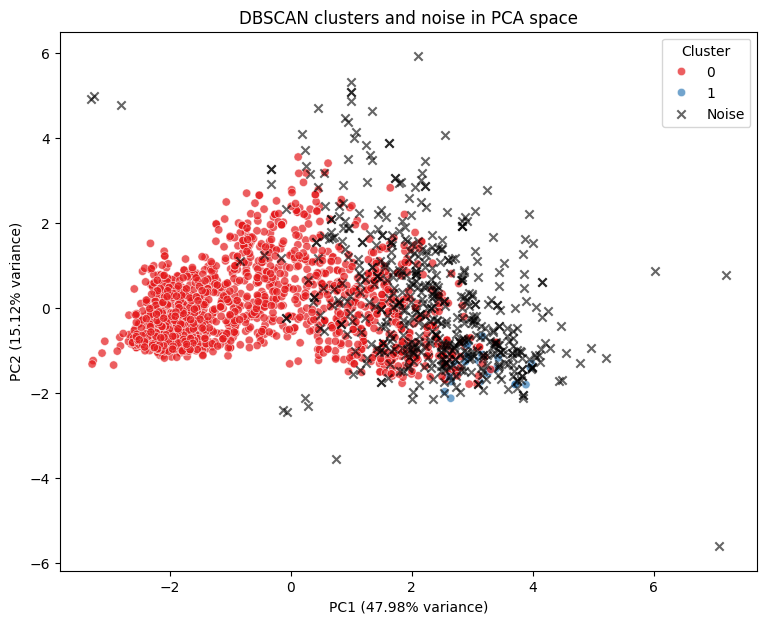

In [25]:
dbscan_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

dbscan_pca_df["Cluster"] = dbscan_labels

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=dbscan_pca_df[dbscan_pca_df["Cluster"] != -1],
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.7
)

plt.scatter(
    dbscan_pca_df.loc[dbscan_pca_df["Cluster"] == -1, "PC1"],
    dbscan_pca_df.loc[dbscan_pca_df["Cluster"] == -1, "PC2"],
    c="black",
    marker="x",
    alpha=0.6,
    label="Noise"
)

plt.title("DBSCAN clusters and noise in PCA space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.legend(title="Cluster")
plt.show()

**How sensitive was DBSCAN to eps and min_samples?**

DBSCAN was highly sensitive to the choice of eps and min_samples. Small changes in these parameters produced very different numbers of clusters and noise points.

For example,
* with eps=0.5 and min_samples=5, DBSCAN produced 7 clusters and classified 67.66% of points as noise.
* With eps=0.9 and min_samples=10, it produced 2 clusters but classified 48.37% of points as noise.
* At eps=1.3 and min_samples=15, it made 2 clusters with 23.09% noise and achieved the highest valid silhouette score of 0.3785.
* Larger eps values of 1.5 caused most points to merge into only one cluster.


Therefore, the results demonstrate that DBSCAN is sensitive to its density parameters, and appropriate parameter selection is important.

In [26]:
dbscan_data = X.copy()

dbscan_data["DBSCAN_Cluster"] = dbscan_labels

noise_points = dbscan_data[
    dbscan_data["DBSCAN_Cluster"] == -1
]

print("Number of noise points:", len(noise_points))

display(noise_points.head())

Number of noise points: 517


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,DBSCAN_Cluster
0,58138.0,58,635,546,3,8,10,4,-1
15,82800.0,23,1006,115,1,7,6,12,-1
18,76995.0,91,1012,498,2,11,4,9,-1
21,2447.0,42,1,1725,15,0,28,0,-1
22,58607.0,63,867,86,3,2,3,9,-1


**Which points were considered noise and why might that be useful?**

DBSCAN classified 517 customers. 23.09% of the dataset was noise. These points did not belong to a really dense region according to the selected eps=1.3 and min_samples=15 parameters. This is useful because DBSCAN does not force every customer into a cluster. Customers with unusual combinations can be identified as being outliers